### Exploratory Data Analysis  
##### Roles to Explore:

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
from pathlib import Path

# Loading already cleaned data
Base_path = Path().resolve().parent
DATA_PATH = Base_path / "data" / "processed_data" / "job_postings_data_cleaned.parquet"
df = pd.read_parquet(DATA_PATH)


print("Lib/s loaded and data ready")

Lib/s loaded and data ready


In [2]:
df_DA_IN = df[(df['job_country'] == 'India') & (df['job_title_short'] == 'Data Analyst')]

# filtering out locations of which specific location in India is not given.
df_loc_plot = df_DA_IN.query('job_location !="India"')['job_location'].value_counts().head(10).to_frame()
df_loc_plot

,count
job_location,
"Hyderabad, Telangana, India",1289
Anywhere,1052
"Bengaluru, Karnataka, India",355
"Maharashtra, India",203
"Mumbai, Maharashtra, India",133
"Pune, Maharashtra, India",119
"Gurugram, Haryana, India",108
"Chennai, Tamil Nadu, India",106
"Secunderabad, Telangana, India",84


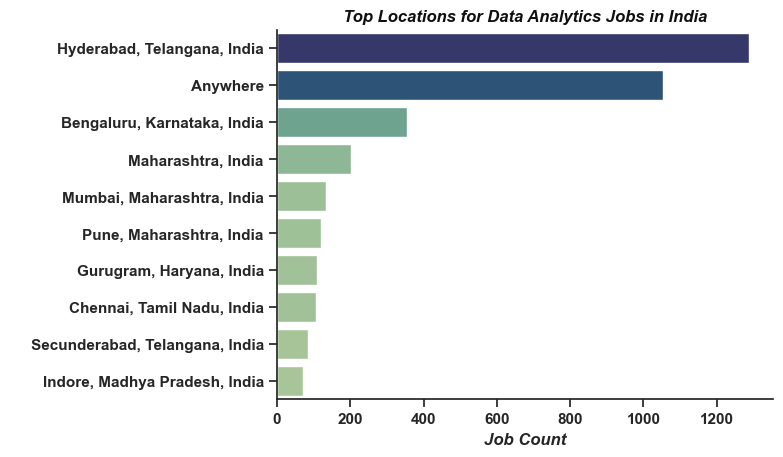

In [3]:
plt.rcParams.update({ 'font.weight': 'bold',
    'axes.titleweight': 'bold',
    'axes.labelweight': 'bold',
    'axes.labelcolor': "#2A2B2E",
    'text.color': '#2A2B2E',
    'axes.titlecolor': "#111010",
    'xtick.color': "#2A2B2E",
    'ytick.color': '#2A2B2E',
    'axes.titlesize':18
    })

sns.set_theme(style='ticks')
sns.set_context('notebook')

sns.barplot(data=df_loc_plot, x='count', 
            y='job_location', hue='count', 
            palette='crest', legend=False)

sns.despine()
plt.title('Top Locations for Data Analytics Jobs in India', 
          fontstyle='italic')
plt.ylabel(' ')
plt.xlabel('Job Count', fontstyle='italic')
plt.show()



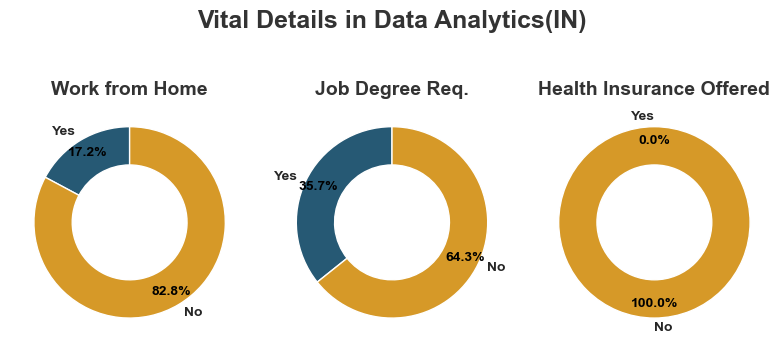

In [4]:
fig, ax = plt.subplots(1, 3, figsize=(8,4))

dict_columns = {'job_work_from_home':'Work from Home',
                'job_no_degree_mention':'Job Degree Req.',
                'job_health_insurance':'Health Insurance Offered'
                }

for i, (column, title) in enumerate(dict_columns.items()):
    counts = df_DA_IN[column].value_counts().reindex([True, False], 
                                                     fill_value=0)
    wedges, texts, autotexts = ax[i].pie(counts,
                                 labels = counts.index.map(
                                     {True: 'Yes', False: 'No'}),
                                 autopct='%1.1f%%',
                                 startangle=90,
                                 pctdistance=.85,
                                 wedgeprops={'width':0.4},
                                 colors=["#265974", "#D69928"]  
                                     )
    ax[i].set_title(title, fontsize=14, fontweight='bold', 
                    color="#333333")
    plt.setp(texts, fontsize=10)
    plt.setp(autotexts, color='black', fontsize=10)                  
                                    
                                 
                                                 
    
plt.suptitle('Vital Details in Data Analytics(IN)', 
             fontsize=18, fontweight='bold', color="#333333")

plt.tight_layout()
plt.show()

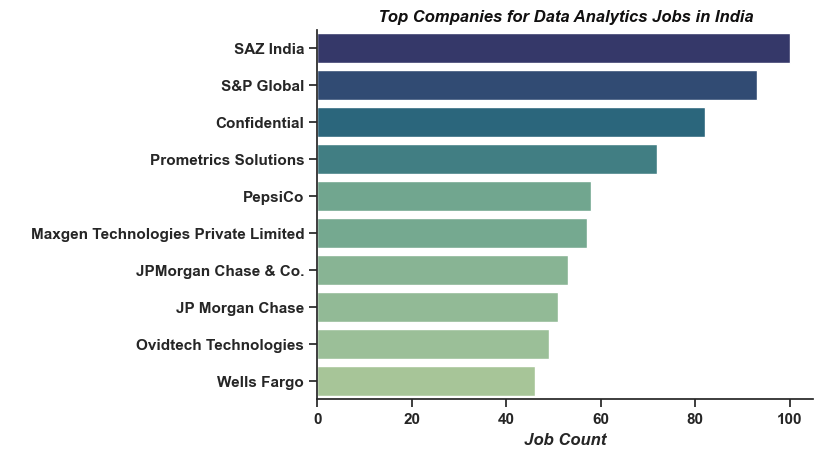

In [5]:
df_com_plot = df_DA_IN['company_name'].value_counts().head(10).to_frame()

sns.set_theme(style='ticks')

sns.barplot(data=df_com_plot, x='count', 
            y='company_name', hue='count', 
            palette='crest', legend=False)

sns.despine()
plt.title('Top Companies for Data Analytics Jobs in India', 
          fontstyle='italic')

plt.ylabel(' ')
plt.xlabel('Job Count', fontstyle='italic')

plt.show()

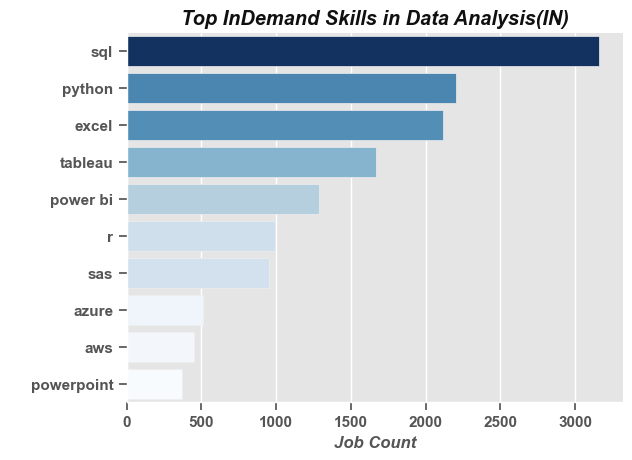

In [ ]:
skills_explode = df_DA_IN.explode('job_skills')

top_skills = skills_explode['job_skills'].value_counts().head(10).to_frame()

plt.style.use('ggplot')
sns.barplot(data=top_skills, x='count', 
            y='job_skills', hue='count', palette='Blues',
            legend=False)
sns.despine()

plt.title('Top InDemand Skills in Data Analysis(IN)', 
          fontstyle='italic')

plt.ylabel(' ')
plt.xlabel('Job Count', fontstyle='italic')

plt.show()

